### DBSCAN sklearn demo

In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_moons

from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns

from kneed import KneeLocator

sns.set_theme()
plt.rcParams['image.cmap'] = 'tab10'

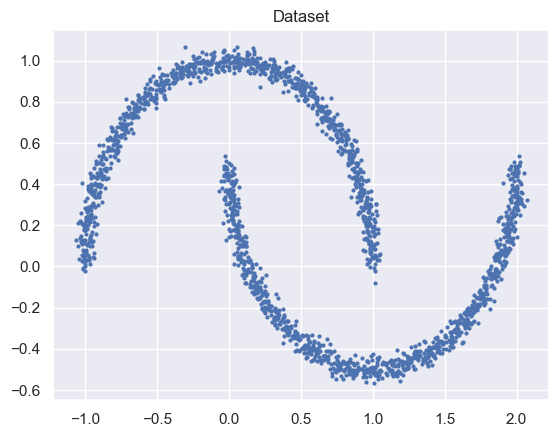

In [6]:
X, y = make_moons(n_samples=2000,
                  shuffle=True,
                  noise=0.03,
                  random_state=42)

plt.figure()
plt.scatter(X[:,0], X[:,1], s=4)
plt.title("Dataset")
plt.show()

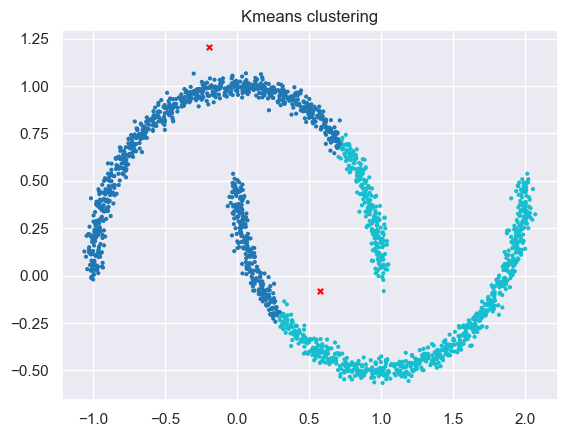

In [12]:
# get the kmeans clustering for the given data
kmeans = KMeans(n_clusters=2,
                random_state=42,
                n_init='auto')
kmeans.fit(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1],c=kmeans.labels_, s=4)
plt.scatter(kmeans.cluster_centers_[0], kmeans.cluster_centers_[1], s=15,marker='x', c='red')
plt.title('Kmeans clustering')
plt.show()

#### Clustering with Raw DBSCAN

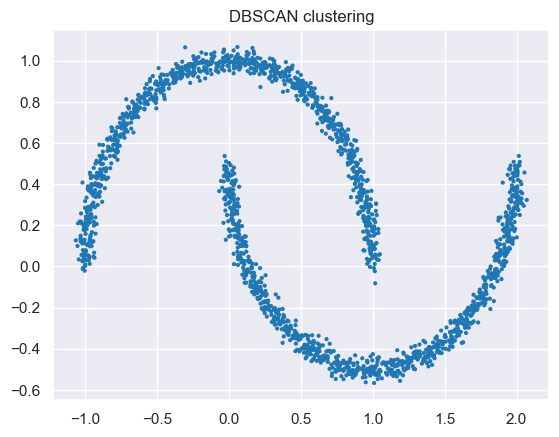

In [14]:
dbscan = DBSCAN()
_ = dbscan.fit(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=4)
plt.title("DBSCAN clustering")
plt.show()

#### Tuning DBSCAN parameters

In [16]:
# identify the min point (recommended way)
min_point = X.shape[1] * 2

# find the distances to the min_point'th neighbour
nearest_neigh = NearestNeighbors().fit(X)
distance, _ = nearest_neigh.kneighbors(X=X,n_neighbors=min_point)
distance

array([[0.        , 0.01565356, 0.01813654, 0.01851042],
       [0.        , 0.0105718 , 0.01916798, 0.02125814],
       [0.        , 0.01237228, 0.0155384 , 0.0195213 ],
       ...,
       [0.        , 0.01657639, 0.01661593, 0.02006599],
       [0.        , 0.00806393, 0.01265358, 0.01738457],
       [0.        , 0.00621763, 0.00679906, 0.01497915]])

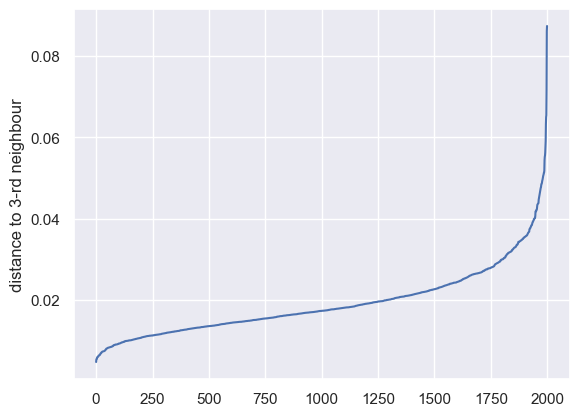

In [25]:
# sort the min_dist of the last neighbour
sort_dist = np.sort(distance[:, -1])

# plot the graph of the sorted neighbour
plt.figure()
plt.plot(range(sort_dist.shape[0]), sort_dist)
plt.ylabel("distance to {}-rd neighbour".format(min_point-1))
plt.show()

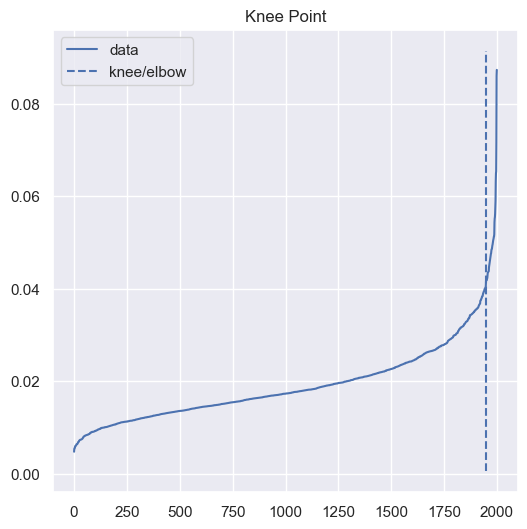

In [26]:
kneedle = KneeLocator(
    x=range(sort_dist.shape[0]),
    y=sort_dist,
    S=1.0,
    curve='convex',
    direction='increasing'
)

kneedle.plot_knee()

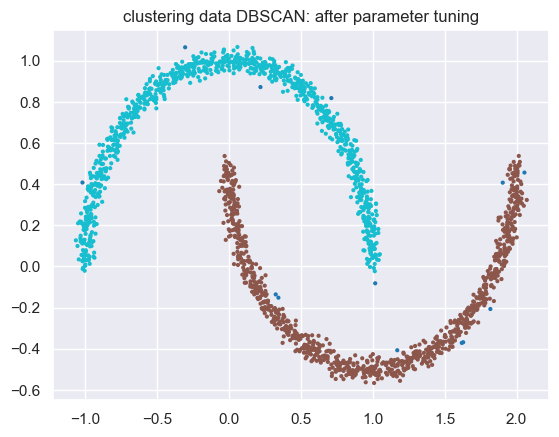

In [27]:
# now taking the reference from above values plot the DBSCAN again
dbscan = DBSCAN(eps=0.04, min_samples=4)
_ = dbscan.fit(X)

plt.figure()
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_, s=4)
plt.title("clustering data DBSCAN: after parameter tuning")
plt.show()

In [28]:
silhouette_score(X, kmeans.labels_)

0.4923222280372994

In [29]:
silhouette_score(X, dbscan.labels_)

0.2188825463792817